In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

workpath = '/content/drive/MyDrive/DigitalImageProcessing/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading images...
Image size: 1390x1110
Running OpenCV StereoSGBM...


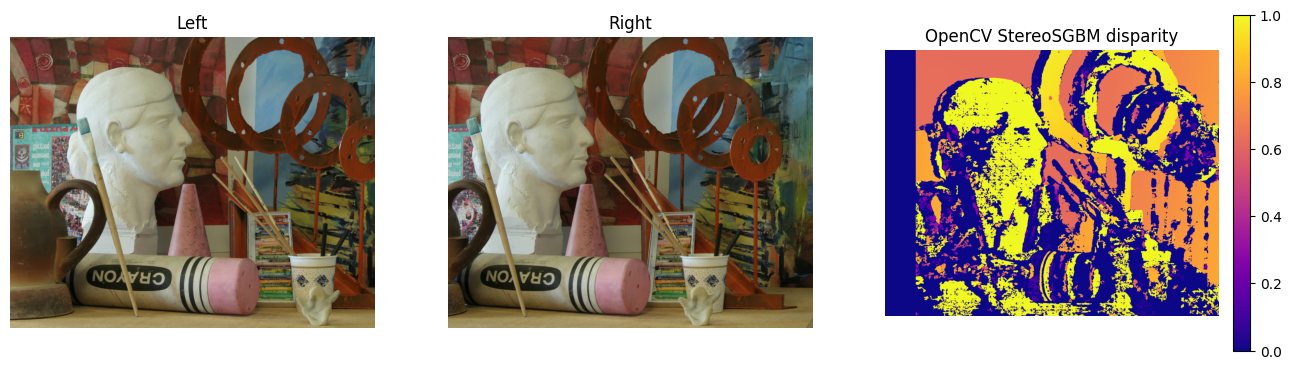

In [ ]:
import os, sys, urllib.request, io
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Input images
IMG1 = workpath + "Data/view1.png"   # left
IMG2 = workpath + "Data/view5.png"   # right

# SGBM parameters (if using OpenCV)
MIN_DISPARITY = 0
NUM_DISPARITIES = 128   # must be divisible by 16
BLOCK_SIZE = 7
P1 = 8 * 3 * BLOCK_SIZE**2
P2 = 32 * 3 * BLOCK_SIZE**2
MODE = "MODE_SGBM"       # or "MODE_HH" for full-scale slower mode

# ---------------- End USER CONFIG ----------------



def pil_to_numpy_gray(img):
    return np.asarray(img.convert("L"))  # grayscale (H, W) uint8

def show_images_and_disparity(imgL_pil, imgR_pil, disp_float, title="Disparity"):
    # disp_float: HxW float disparity (un-normalized)
    fig, axes = plt.subplots(1,3, figsize=(16,6))
    axes[0].imshow(imgL_pil)
    axes[0].set_title("Left")
    axes[0].axis("off")
    axes[1].imshow(imgR_pil)
    axes[1].set_title("Right")
    axes[1].axis("off")
    ax = axes[2]
    # Normalize for display
    vmin = np.percentile(disp_float, 2)
    vmax = np.percentile(disp_float, 98)
    disp_norm = (disp_float - vmin) / (vmax - vmin + 1e-8)
    # disp_norm[disp_norm <= -0.1] = np.nan
    disp_norm = np.clip(disp_norm, 0.0, 1.0)
    im = ax.imshow(disp_norm, cmap="plasma", vmax=1, vmin=0)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# ---------------- Load images ----------------
print("Loading images...")
img1_pil = Image.open(IMG1)
img2_pil = Image.open(IMG2)
if img1_pil.size != img2_pil.size:
    print("Warning: left and right image sizes differ. Resizing right to left's size for matching.")
    img2_pil = img2_pil.resize(img1_pil.size, Image.BILINEAR)

H, W = img1_pil.size[1], img1_pil.size[0]
print(f"Image size: {W}x{H}")

# ---------------- OpenCV StereoSGBM inference ----------------
print("Running OpenCV StereoSGBM...")
# Convert to grayscale numpy arrays
left_gray = pil_to_numpy_gray(img1_pil)
right_gray = pil_to_numpy_gray(img2_pil)

# Ensure NUM_DISPARITIES is divisible by 16
num_disp = int(NUM_DISPARITIES)
if num_disp % 16 != 0:
    num_disp = (num_disp // 16 + 1) * 16
    print("Adjusted NUM_DISPARITIES to", num_disp, "(must be divisible by 16)")

mode_flag = cv2.StereoSGBM_MODE_SGBM if MODE == "MODE_SGBM" else cv2.StereoSGBM_MODE_HH

sgbm = cv2.StereoSGBM_create(
    minDisparity = int(MIN_DISPARITY),
    numDisparities = num_disp,
    blockSize = int(BLOCK_SIZE),
    P1 = int(P1),
    P2 = int(P2),
    disp12MaxDiff = 1,
    uniquenessRatio = 10,
    speckleWindowSize = 100,
    speckleRange = 32,
    preFilterCap = 63,
    mode = mode_flag
)
disp16 = sgbm.compute(left_gray, right_gray).astype(np.int16)
# OpenCV returns 16-bit fixed-point disparity (scaled by 16)
disp = disp16.astype(np.float32) / 16.0

show_images_and_disparity(img1_pil, img2_pil, disp, title="OpenCV StereoSGBM disparity")

